<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/Distribuci%C3%B3n%20de%20Poisson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### <span style="color:green;">**ACTIVIDAD**</span>



**Alumna: Florencio Florencio Miriam Lizeth**

**Objetivo:** Es poder simular y analizar fenómenos aleatorios de conteo, es decir, situaciones donde queremos saber cuántas veces ocurre un evento en un intervalo determinado.

# **Distribución de Poisson**

Para simular esta variable usaremos la identidad: $$p_{i+1}=\frac{λ}{i+1}p_i$$ con $i≥0$  para aplicar el metodo de la Transformada Inverda **
**Una variable $x$ en Poisson con media $λ$ si** **$$p=P\{X=i\}=e^{-λ}\frac{λ^i}{i!}$$** **con  $i=0,1,2,3,4,...$**

**INTERPRETACION**


Una variable aleatoria \(X\) sigue una distribución de Poisson con media \(λ\) si la probabilidad de observar \(i\) eventos está dada por

$$P(X=i)=e^{-\lambda}\frac{\lambda^i}{i!},
\qquad i=0,1,2,\dots$$


Esta distribución se utiliza para modelar el número de ocurrencias de un evento en un intervalo fijo de tiempo, espacio o distancia.

Para simular una variable Poisson mediante el método de la transformada inversa, se emplea la relación recursiva


$$p_{i+1}=\frac{\lambda}{i+1}p_i,
\qquad i\geq 0,
$$

la cual permite calcular cada probabilidad a partir de la anterior sin evaluar factoriales repetidamente, haciendo más eficiente la generación de valores aleatorios Poisson.

**Características importantes**

* Para usar Poisson normalmente se supone que:
* Los eventos ocurren independientemente.
* La tasa promedio λ es constante.Dos eventos no ocurren exactamente al mismo instante.
* Se cuentan eventos en intervalos.

**Relación con otras distribuciones**
La Poisson:
* Aproxima una Binomial cuando n es grande y p pequeño.
* Está relacionada con la distribución exponencial en procesos de llegada.

En resumen, la  **generación de una variable aleatoria Poisson** se utiliza para:modelar conteos aleatorios,simular eventos,analizar llegadas y ocurrencias,resolver problemas reales de colas, tráfico, fallas y demanda.Es una de las distribuciones más importantes en probabilidad aplicada y simulación.

Ahora bien, consideremos del siguiente Seudocódigo para programar la **Distribución de Poisson** :

Seudocódigo (Viene en el Ross)

1. Generar $ R\sim U(0,1)$

2. i = 0 , $ p = e^{-λ}$ , $ F = p$

3. Si  U < F   Hacer  X = i  y terminar


4. $p = \frac{λp}{i+1}$ , $  F = F + p$ ,   $i = i + 1$
5. Ir al paso 3

In [6]:

# Importamos librerías
import numpy as np
import random as rr
import math
import matplotlib.pyplot as plt


In [7]:
# Definimos la función
def Poisson(lam, num_elements):

    L = []

    for k in range(num_elements):

        # Paso 1: Generar U~U(0,1)
        U = rr.random()

        # Paso 2
        i = 0
        p = math.exp(-lam)
        F = p

        # Paso 3 y 4
        while U > F:

            p = (lam * p) / (i + 1)
            F = F + p
            i = i + 1

        # Guardamos el valor generado
        L.append(i)

    return L

In [8]:

# Generar 1000 variables Poisson
M = Poisson(lam=4, num_elements=1000)


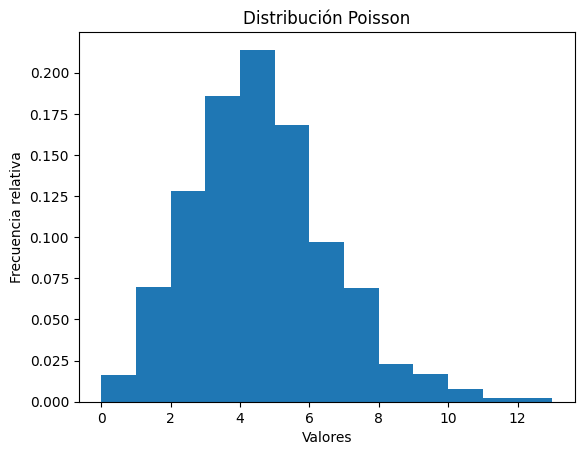

In [10]:
plt.hist(M, density=True, bins=range(min(M), max(M)+2))
plt.xlabel("Valores")
plt.ylabel("Frecuencia relativa")
plt.title("Distribución Poisson")
plt.show()

In [12]:
import time

print("Iniciando una demora de 2 segundos...")
time.sleep(2) # Pause execution for 2 seconds
print("¡Demora finalizada!")

Iniciando una demora de 2 segundos...
¡Demora finalizada!


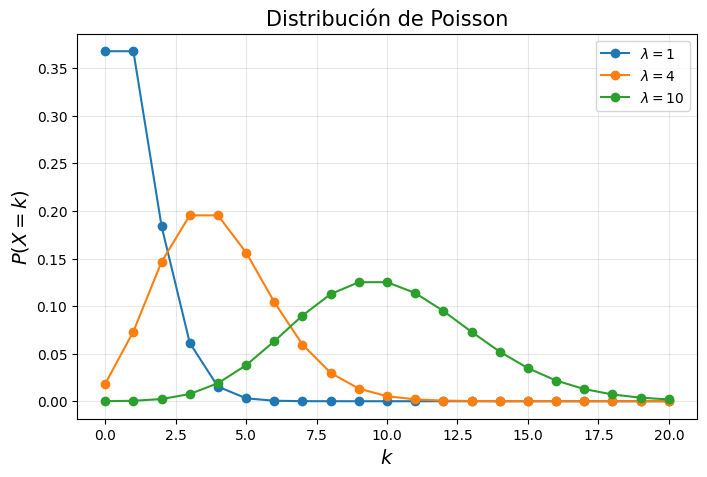

In [15]:
from scipy.stats import poisson

# Definir el rango de k (número de eventos)
k = np.arange(0, 21)  # Desde 0 hasta 20

# Calcular la función de masa de probabilidad (PMF) para diferentes lambdas
p1 = poisson.pmf(k, mu=1)   # lambda = 1
p2 = poisson.pmf(k, mu=4)   # lambda = 4
p3 = poisson.pmf(k, mu=10)  # lambda = 10

plt.figure(figsize=(8,5))

plt.plot(k, p1, 'o-', label=r'$\lambda=1$')
plt.plot(k, p2, 'o-', label=r'$\lambda=4$')
plt.plot(k, p3, 'o-', label=r'$\lambda=10$')

# Etiquetas
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$P(X=k)$', fontsize=14)

# Título
plt.title('Distribución de Poisson', fontsize=15)

# Cuadrícula
plt.grid(True, alpha=0.3)

# Leyenda
plt.legend()

# Mostrar gráfica
plt.show()

### <span style="color:teal;">**Conclusión:**</span>

Ha sido fascinante explorar esta distribución, una herramienta superútil para entender y predecir el número de veces que ocurren eventos en un período o espacio determinado. Empezamos conociendo su base matemática y cómo podemos simularla de una forma bastante ingeniosa usando un truco con las probabilidades. De hecho, hemos puesto manos a la obra y programado una función para generar estos números aleatorios de Poisson, ¡y hasta hemos visto cómo se ven en un histograma!

Lo más interesante es que hemos podido comparar cómo se comporta la distribución cuando cambiamos el valor de $\lambda$ (la media). Esto nos ha dado una idea muy clara de su versatilidad y de por qué es tan importante en tantos campos, desde la gestión de filas en un supermercado hasta el análisis de fallos en sistemas. Espero que esto te haya dado una buena base para seguir explorando el mundo de la probabilidad y la simulación.